In [7]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

In [15]:

def gen_noise(t, sd, coarse_step): #noise generation code, generate bandlimited noise
    t_start, t_end = t[0], t[-1]
    t_coarse = np.arange(t_start, t_end, coarse_step)
    # Generate WGN at coarse sampling rate
    coarse_noise = np.random.normal(0, sd, size=len(t_coarse))
    # Sample-and-hold interpolation (nearest neighbor)
    wgn = np.interp(t, t_coarse, coarse_noise, left=coarse_noise[0], right=coarse_noise[-1])
    return wgn

def noise_spectral_analysis(noise, fs):
    freq, psd = sc.signal.periodogram(noise, fs, window = "boxcar")
    # mv average
    window_size = 500
    psd_mva = [psd[0]]
    for i in range(1, len(psd)):
        if i < window_size:
            psd_mva.append(np.mean(psd[0:i+1]))
        else:
            psd_mva.append(psd_mva[i-1] + (psd[i] - psd[i - window_size]) / window_size)
    return freq, psd, psd_mva

def autocorrelation_analysis(noise):
    n = len(noise)
    noise = noise - np.mean(noise)  # zero-mean
    nfft = 2**int(np.ceil(np.log2(2*n - 1)))
    f = np.fft.fft(noise, nfft)
    acf = np.real(np.fft.ifft(f * np.conjugate(f)))
    # Only first 2N-1 lags are valid
    acf = acf[:n]
    # acf /= (np.var(noise) * n)
    lags = np.arange(0, n)
    return lags, acf

In [9]:
dt = 10e-9
tend = 0.1
t = np.arange(0, tend, dt)
sd = 1
coarse_step = 10e-6
wgn = gen_noise(t, sd, coarse_step)

In [16]:
# Power Spectral Density Analysis
freq, psd, psd_mva = noise_spectral_analysis(wgn, 1/dt)
psd_db = 10 * np.log10(psd)
psd_mva_db = 10 * np.log10(psd_mva)

# Autocorrelation Analysis
lags, autocorr = autocorrelation_analysis(wgn)
autocorr_2side = np.concatenate((autocorr[::-1], autocorr[1:]))
lags_2side = np.arange(-len(autocorr)+1, len(autocorr))

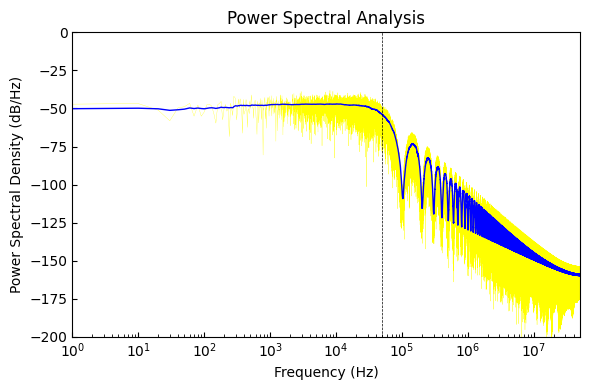

In [14]:
plt.figure(figsize=(6, 4))
plt.semilogx(freq, psd_db, color='yellow', linewidth = 0.2)
plt.semilogx(freq, psd_mva_db, color='blue', linewidth = 1)
plt.axvline(x=1/(2*coarse_step), color='black', linestyle='--', linewidth=0.5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (dB/Hz)')
plt.title('Power Spectral Analysis')
plt.tick_params(axis='both', which='both', direction='in')
plt.xlim(1, 1/(2*dt))
plt.ylim(-200, 00)
plt.tight_layout()

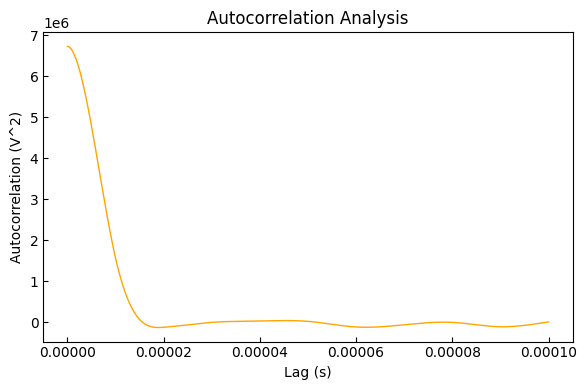

In [24]:
plt.figure(figsize=(6, 4))
plt.plot(lags[0:10000]*dt, autocorr[0:10000], color='orange', linewidth=1)
plt.xlabel('Lag (s)')
plt.ylabel('Autocorrelation (V^2)')
plt.title('Autocorrelation Analysis')
plt.tick_params(axis='both', which='both', direction='in')
plt.tight_layout()

In [46]:
bw = np.logspace(4, 6, 10)
dt = 10e-9
tend = 0.1
t = np.arange(0, tend, dt)
sd = 1
acf = []
PSD = []
PSD_mva = []
for f in bw:
    coarse_step = 1/f
    wgn = gen_noise(t, sd, coarse_step)
    # Power Spectral Density Analysis
    freq, psd, psd_mva = noise_spectral_analysis(wgn, 1/dt)
    psd_db = 10 * np.log10(psd)
    PSD.append(psd_db)
    psd_mva_db = 10 * np.log10(psd_mva)
    PSD_mva.append(psd_mva_db)

    # Autocorrelation Analysis
    lags, ac = autocorrelation_analysis(wgn)
    acf.append(ac)

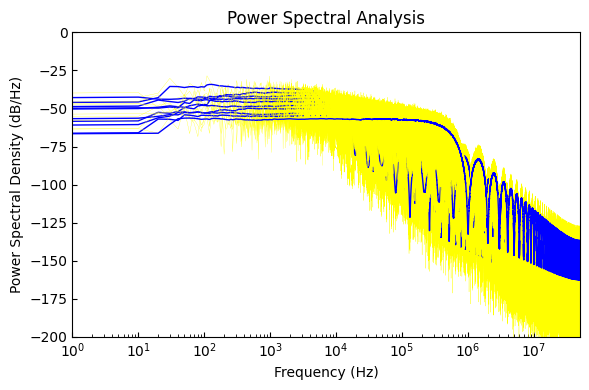

In [47]:
plt.figure(figsize=(6, 4))
for i in range(len(bw)):
    plt.semilogx(freq, PSD[i], color='yellow', linewidth = 0.2)
    plt.semilogx(freq, PSD_mva[i], color='blue', linewidth = 1)
    plt.axvline(x=1/(bw[i]), color='black', linestyle='--', linewidth=0.5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (dB/Hz)')
plt.title('Power Spectral Analysis')
plt.tick_params(axis='both', which='both', direction='in')
plt.xlim(1, 1/(2*dt))
plt.ylim(-200, 00)
plt.tight_layout()

In [59]:
PSD_bw

[0.0001308215136133496,
 9.433078567846464e-05,
 6.554023542847282e-05,
 4.430526156663031e-05,
 2.6727407688129604e-05,
 1.5707661068881907e-05,
 8.891805106886917e-06,
 4.99733543278293e-06,
 3.292539267684577e-06,
 2.0800529014601747e-06]

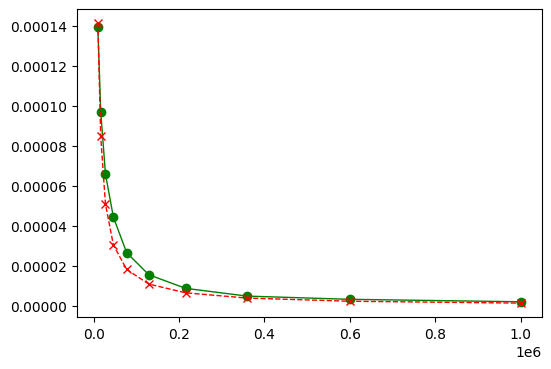

In [72]:
PSD_bw = [10**(PSD_mva[i][450]/10) for i in range(len(bw))]
plt.figure(figsize=(6, 4))
plt.plot(bw, PSD_bw, marker='o', linestyle='-', color='green', linewidth=1)
plt.plot(bw, [sd**2]*len(bw)/bw*np.sqrt(2), marker='x', linestyle='--', color='red', linewidth=1)

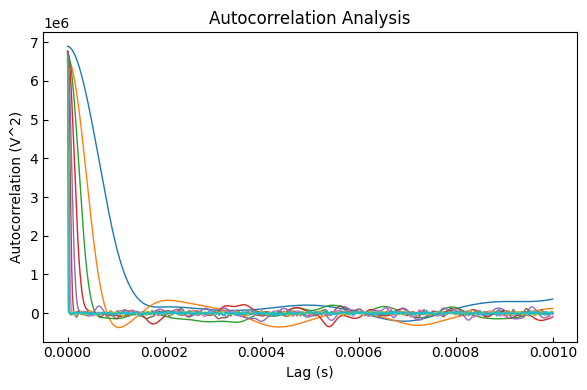

In [61]:
plt.figure(figsize=(6, 4))
to = 100000
for i in range(len(bw)):
    plt.plot(lags[0:to]*dt, acf[i][0:to], label=f'BW={bw[i]/1e6}MHz', linewidth=1)
plt.xlabel('Lag (s)')
plt.ylabel('Autocorrelation (V^2)')
plt.title('Autocorrelation Analysis')
plt.tick_params(axis='both', which='both', direction='in')
plt.tight_layout()